In [1]:
import torch
import torch.nn as nn
import cv2

In [2]:
import os
import glob
import torch
import numpy as np
from torch.utils.data import Dataset, DataLoader
from skimage import io, color, transform

class PairedColorizationDataset(Dataset):
    def __init__(self, black_dir, color_dir, image_size=256):
       
        self.black_paths = sorted(glob.glob(os.path.join(black_dir, "*.jpg")) + 
                                  glob.glob(os.path.join(black_dir, "*.png")))
        self.color_paths = sorted(glob.glob(os.path.join(color_dir, "*.jpg")) + 
                                  glob.glob(os.path.join(color_dir, "*.png")))
        self.image_size = image_size
        assert len(self.black_paths) == len(self.color_paths), \
            "Mismatch between black and color images count!"

    def __len__(self):
        return len(self.black_paths)

    def __getitem__(self, idx):
        # Read grayscale (input)
        gray_img = io.imread(self.black_paths[idx])
        if len(gray_img.shape) == 3:  # if RGB, convert to grayscale
            gray_img = color.rgb2gray(gray_img)
        gray_img = transform.resize(gray_img, (self.image_size, self.image_size), anti_aliasing=True)

        # Read color (target)
        color_img = io.imread(self.color_paths[idx])
        if len(color_img.shape) == 2:
            color_img = np.stack((color_img,) * 3, axis=-1)
        elif color_img.shape[2] == 4:
            color_img = color_img[:, :, :3]
        color_img = transform.resize(color_img, (self.image_size, self.image_size), anti_aliasing=True)

        # Convert to LAB color space
        lab = color.rgb2lab(color_img).astype("float32")
        L_target = lab[:, :, 0] / 100.0
        ab_target = lab[:, :, 1:] / 128.0

        # Replace L channel with grayscale input (for realism)
        L_input = gray_img.astype("float32")

        # Convert to tensors
        L_input = torch.from_numpy(L_input).unsqueeze(0)       # (1, H, W)
        ab_target = torch.from_numpy(ab_target).permute(2, 0, 1)  # (2, H, W)

        return L_input, ab_target


def get_dataloaders(base_path="/kaggle/input/image-colorization-dataset/data", 
                    batch_size=8, image_size=256):

    train_black = os.path.join(base_path, "train_black")
    train_color = os.path.join(base_path, "train_color")
    test_black = os.path.join(base_path, "test_black")
    test_color = os.path.join(base_path, "test_color")

    train_dataset = PairedColorizationDataset(train_black, train_color, image_size=image_size)
    test_dataset = PairedColorizationDataset(test_black, test_color, image_size=image_size)

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2)

    return train_loader, test_loader


train_loader, test_loader = get_dataloaders()

L, ab = next(iter(train_loader))
print("L shape:", L.shape)    # [B, 1, H, W]
print("ab shape:", ab.shape)  # [B, 2, H, W]


L shape: torch.Size([8, 1, 256, 256])
ab shape: torch.Size([8, 2, 256, 256])


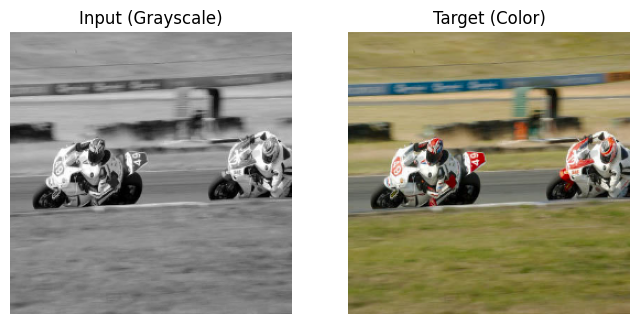

In [3]:
import matplotlib.pyplot as plt
from skimage.color import lab2rgb

def show_sample(L, ab):
    L = L[0].numpy().transpose(1, 2, 0)
    ab = ab[0].numpy().transpose(1, 2, 0)
    lab = np.concatenate((L * 100, ab * 128), axis=2)
    img_rgb = lab2rgb(lab)

    plt.figure(figsize=(8, 4))
    plt.subplot(1, 2, 1)
    plt.imshow(L.squeeze(), cmap='gray')
    plt.title("Input (Grayscale)")
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.imshow(img_rgb)
    plt.title("Target (Color)")
    plt.axis("off")
    plt.show()

show_sample(L, ab)


In [4]:
import torch
import torch.nn as nn

class U_Net(nn.Module):
    def __init__(self):
        super(U_Net, self).__init__()

        self.encoder = self.encoder_block(in_channels=1, out_channels=64)
        self.decoder = self.decoder_block(in_channels=64, out_channels=64)

        # output 2 channels (a,b)
        self.final_conv = nn.Conv2d(64, 2, kernel_size=1)

    def encoder_block(self, in_channels, out_channels):
        return nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=1, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=1, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )

    def decoder_block(self, in_channels, out_channels):
        return nn.Sequential(
            nn.ConvTranspose2d(in_channels, out_channels, kernel_size=2, stride=2),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=1, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=1, padding=1),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        x = self.encoder(x)
        x = self.decoder(x)
        x = self.final_conv(x)
        return x


In [ ]:
import torch.nn as nn
import torch.optim as optim

device = "cuda" if torch.cuda.is_available() else "cpu"
model = U_Net().to(device)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)

for epoch in range(10):
    model.train()
    running_loss = 0.0
    for L, ab in train_loader:
        L, ab = L.to(device), ab.to(device)
        output_ab = model(L)
        loss = criterion(output_ab, ab)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    print(f"Epoch [{epoch+1}/10], Loss: {running_loss/len(train_loader):.4f}")


Epoch [1/10], Loss: 0.0126


In [ ]:
import os
import numpy as np
from skimage.color import lab2rgb
import imageio


save_preds = True            
save_dir = "/kaggle/working/predicted_color" 
num_save_batches = 3           

os.makedirs(save_dir, exist_ok=True)

def evaluate(model, test_loader, criterion, device, save_preds=True, save_dir=None, num_save_batches=0):
    model.eval()
    total_mse = 0.0
    total_mae = 0.0
    total_samples = 0

    with torch.no_grad():
        for batch_idx, (L, ab) in enumerate(test_loader):
            batch_size = L.size(0)
            L = L.to(device)           # [B,1,H,W]
            ab = ab.to(device)         # [B,2,H,W]

            pred_ab = model(L)         # [B,2,H,W]

            # losses (per-batch)
            mse_loss = criterion(pred_ab, ab).item()
            mae_loss = torch.mean(torch.abs(pred_ab - ab)).item()

            # accumulate (weight by number of samples in batch)
            total_mse += mse_loss * batch_size
            total_mae += mae_loss * batch_size
            total_samples += batch_size

            # OPTIONAL: save first few batches of predictions as RGB images
            if save_preds and (batch_idx < num_save_batches):
                pred_ab_cpu = pred_ab.cpu().numpy()
                L_cpu = L.cpu().numpy()
                for i in range(batch_size):
                    L_img = L_cpu[i, 0, :, :]           # H x W, in [0,1]
                    ab_img = pred_ab_cpu[i].transpose(1, 2, 0)  # H x W x 2, in [-1,1]

                    # reconstruct LAB (recall our normalization: L/100 and ab/128)
                    lab = np.zeros((L_img.shape[0], L_img.shape[1], 3), dtype=np.float32)
                    lab[:, :, 0] = L_img * 100.0
                    lab[:, :, 1:] = ab_img * 128.0

                    rgb = lab2rgb(lab)  # values in [0,1]
                    rgb_uint8 = (np.clip(rgb, 0, 1) * 255).astype(np.uint8)

                    fname = os.path.join(save_dir, f"test_b{batch_idx}_img{i}.png")
                    imageio.imwrite(fname, rgb_uint8)

    avg_mse = total_mse / total_samples
    avg_mae = total_mae / total_samples

    print(f"Test results — samples: {total_samples}")
    print(f"Average MSE (ab channels): {avg_mse:.6f}")
    print(f"Average MAE (ab channels): {avg_mae:.6f}")

    if save_preds:
        print(f"Saved predictions to: {save_dir} (first {num_save_batches} batches)")

    return avg_mse, avg_mae


avg_mse, avg_mae = evaluate(model, test_loader, criterion, device,
                            save_preds=save_preds, save_dir=save_dir, num_save_batches=num_save_batches)


In [ ]:
# model = U_Net()

In [ ]:
# criterion  = nn.L1Loss()
# optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
# num_epochs = 50

In [ ]:
# x_paths = sorted(glob('/kaggle/working/output/train_black/*.npy'))
# y_paths = sorted(glob('/kaggle/working/output/train_color/*.npy'))

# # Load into memory
# X_train = np.array([np.load(p) for p in x_paths])
# Y_train = np.array([np.load(p) for p in y_paths])

In [ ]:
# X_train = torch.tensor(X_train, dtype=torch.float32)
# Y_train = torch.tensor(Y_train, dtype=torch.float32)

In [ ]:
# X_train=X_train.unsqueeze(1)
# Y_train=Y_train.unsqueeze(1)

In [ ]:
X_train = X_train.permute(0, 3, 2, 1)

In [ ]:
for epoch in range(num_epochs):
    y_output=model(X_train)
    loss=criterion(y_output,Y_train)
    loss.backward()
    optimizer.step()
    optimizer.zero_grad()
    print(f"Loss {loss}")

In [ ]:
X_train.shape